#  Agricultural Information Retrieval System Using TF-IDF and Cosine Similarity

## Project Overview

This project implements an Information Retrieval System for agricultural information using Natural Language Processing techniques.

The system processes agricultural documents and retrieves the most relevant documents for a user's search query.

The project uses:

- Text Preprocessing
- Tokenization
- Stopword Removal
- Stemming
- Term Frequency (TF)
- Document Frequency (DF)
- Inverse Document Frequency (IDF)
- TF-IDF
- Cosine Similarity
- Document Ranking

### Dataset

The system contains four agricultural documents:

1. Crop Cultivation and Soil Management
2. Irrigation and Water Management
3. Pest and Disease Management
4. Organic Farming and Sustainable Agriculture

In [1]:
# Install required NLP library
!pip install nltk -q

In [2]:
import re
import math
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download required NLTK resources
nltk.download('stopwords')

print("Libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...


Libraries imported successfully!


[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
documents = {
    "Text1.txt": """
    Crop cultivation depends on healthy soil, proper nutrients, suitable temperature,
    and appropriate farming practices. Soil preparation is an important step before
    planting crops. Farmers analyze soil fertility and add fertilizers when required.
    Nitrogen, phosphorus, and potassium are important nutrients for crop growth.
    Crop rotation helps maintain soil fertility and reduces nutrient depletion.
    Farmers should select suitable seeds according to soil conditions and climate.
    Proper soil management improves crop productivity and supports healthy plant growth.
    """,

    "Text2.txt": """
    Irrigation is the artificial application of water to agricultural fields.
    Proper irrigation is important for crop production, especially when rainfall is
    insufficient. Drip irrigation supplies water directly to the roots of plants and
    reduces water wastage. Sprinkler irrigation distributes water over crops using
    pipes and sprinklers. Efficient water management improves crop productivity.
    Farmers can use irrigation scheduling to provide crops with the required amount
    of water at the appropriate growth stage.
    """,

    "Text3.txt": """
    Agricultural crops can be affected by insects, pests, fungi, bacteria, and viruses.
    Pest management helps protect crops from damage and disease. Farmers can identify
    symptoms such as leaf spots, wilting, discoloration, and insect damage.
    Biological control uses natural organisms to reduce harmful pests. Integrated pest
    management combines biological, cultural, mechanical, and chemical methods.
    Early detection of crop diseases helps farmers prevent the spread of infection
    and reduce crop losses.
    """,

    "Text4.txt": """
    Organic farming is an agricultural method that focuses on sustainable crop
    production and environmental protection. Organic farmers use compost, organic
    manure, crop residues, and natural fertilizers to improve soil fertility.
    Organic farming reduces the excessive use of synthetic chemicals and supports
    biodiversity. Crop rotation, composting, natural pest control, and soil conservation
    are important sustainable farming practices. Organic agriculture can improve soil
    health and promote environmentally friendly food production.
    """
}

print("Documents created successfully!")
print("Number of documents:", len(documents))

Documents created successfully!
Number of documents: 4


In [4]:
for filename, content in documents.items():
    print("=" * 70)
    print(filename)
    print("=" * 70)
    print(content.strip())
    print()

Text1.txt
Crop cultivation depends on healthy soil, proper nutrients, suitable temperature,
    and appropriate farming practices. Soil preparation is an important step before
    planting crops. Farmers analyze soil fertility and add fertilizers when required.
    Nitrogen, phosphorus, and potassium are important nutrients for crop growth.
    Crop rotation helps maintain soil fertility and reduces nutrient depletion.
    Farmers should select suitable seeds according to soil conditions and climate.
    Proper soil management improves crop productivity and supports healthy plant growth.

Text2.txt
Irrigation is the artificial application of water to agricultural fields.
    Proper irrigation is important for crop production, especially when rainfall is
    insufficient. Drip irrigation supplies water directly to the roots of plants and
    reduces water wastage. Sprinkler irrigation distributes water over crops using
    pipes and sprinklers. Efficient water management improves crop p

In [5]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenization
    tokens = text.split()

    # Stopword removal
    tokens = [word for word in tokens if word not in stop_words]

    # Stemming
    tokens = [stemmer.stem(word) for word in tokens]

    return tokens


processed_documents = {}

for filename, content in documents.items():
    processed_documents[filename] = preprocess(content)

print("Preprocessing completed!")

Preprocessing completed!


In [6]:
for filename, tokens in processed_documents.items():
    print("=" * 70)
    print(filename)
    print("Processed Tokens:")
    print(tokens)
    print()

Text1.txt
Processed Tokens:
['crop', 'cultiv', 'depend', 'healthi', 'soil', 'proper', 'nutrient', 'suitabl', 'temperatur', 'appropri', 'farm', 'practic', 'soil', 'prepar', 'import', 'step', 'plant', 'crop', 'farmer', 'analyz', 'soil', 'fertil', 'add', 'fertil', 'requir', 'nitrogen', 'phosphoru', 'potassium', 'import', 'nutrient', 'crop', 'growth', 'crop', 'rotat', 'help', 'maintain', 'soil', 'fertil', 'reduc', 'nutrient', 'deplet', 'farmer', 'select', 'suitabl', 'seed', 'accord', 'soil', 'condit', 'climat', 'proper', 'soil', 'manag', 'improv', 'crop', 'product', 'support', 'healthi', 'plant', 'growth']

Text2.txt
Processed Tokens:
['irrig', 'artifici', 'applic', 'water', 'agricultur', 'field', 'proper', 'irrig', 'import', 'crop', 'product', 'especi', 'rainfal', 'insuffici', 'drip', 'irrig', 'suppli', 'water', 'directli', 'root', 'plant', 'reduc', 'water', 'wastag', 'sprinkler', 'irrig', 'distribut', 'water', 'crop', 'use', 'pipe', 'sprinkler', 'effici', 'water', 'manag', 'improv', 'cro

In [7]:
def calculate_tf(tokens):
    word_count = Counter(tokens)
    total_words = len(tokens)

    tf = {}

    for word, count in word_count.items():
        tf[word] = count / total_words

    return tf


tf_documents = {}

for filename, tokens in processed_documents.items():
    tf_documents[filename] = calculate_tf(tokens)

print("Term Frequency calculated successfully!")

Term Frequency calculated successfully!


In [8]:
for filename, tf_values in tf_documents.items():
    print("=" * 70)
    print(filename)

    sorted_tf = sorted(
        tf_values.items(),
        key=lambda x: x[1],
        reverse=True
    )

    for word, value in sorted_tf[:10]:
        print(f"{word:20} : {value:.4f}")

Text1.txt
soil                 : 0.1017
crop                 : 0.0847
nutrient             : 0.0508
fertil               : 0.0508
healthi              : 0.0339
proper               : 0.0339
suitabl              : 0.0339
import               : 0.0339
plant                : 0.0339
farmer               : 0.0339
Text2.txt
water                : 0.1200
irrig                : 0.1000
crop                 : 0.0800
product              : 0.0400
sprinkler            : 0.0400
use                  : 0.0400
artifici             : 0.0200
applic               : 0.0200
agricultur           : 0.0200
field                : 0.0200
Text3.txt
crop                 : 0.0755
pest                 : 0.0755
insect               : 0.0377
manag                : 0.0377
help                 : 0.0377
damag                : 0.0377
diseas               : 0.0377
farmer               : 0.0377
biolog               : 0.0377
reduc                : 0.0377
Text4.txt
organ                : 0.0926
farm                 : 0.0556


In [9]:
document_frequency = Counter()

for tokens in processed_documents.values():
    unique_terms = set(tokens)

    for term in unique_terms:
        document_frequency[term] += 1

print("Document Frequency calculated successfully!")
print("Total unique terms:", len(document_frequency))

Document Frequency calculated successfully!
Total unique terms: 108


In [10]:
N = len(documents)

idf_values = {}

for term, df in document_frequency.items():
    idf_values[term] = math.log(N / df)

print("Inverse Document Frequency calculated successfully!")

Inverse Document Frequency calculated successfully!


In [11]:
for term, value in list(idf_values.items())[:20]:
    print(f"{term:20} : {value:.4f}")

practic              : 0.6931
improv               : 0.2877
crop                 : 0.0000
soil                 : 0.6931
condit               : 1.3863
temperatur           : 1.3863
seed                 : 1.3863
climat               : 1.3863
fertil               : 0.6931
plant                : 0.6931
add                  : 1.3863
analyz               : 1.3863
growth               : 0.6931
nutrient             : 1.3863
farmer               : 0.0000
maintain             : 1.3863
depend               : 1.3863
help                 : 0.6931
phosphoru            : 1.3863
requir               : 0.6931


In [12]:
tfidf_documents = {}

for filename, tf_values in tf_documents.items():
    tfidf_documents[filename] = {}

    for term, tf_value in tf_values.items():
        idf_value = idf_values[term]
        tfidf_documents[filename][term] = tf_value * idf_value

print("TF-IDF calculation completed!")

TF-IDF calculation completed!


In [13]:
for filename, tfidf_values in tfidf_documents.items():
    print("=" * 70)
    print(filename)

    sorted_tfidf = sorted(
        tfidf_values.items(),
        key=lambda x: x[1],
        reverse=True
    )

    for term, value in sorted_tfidf[:10]:
        print(f"{term:20} : {value:.4f}")

Text1.txt
soil                 : 0.0705
nutrient             : 0.0705
healthi              : 0.0470
suitabl              : 0.0470
fertil               : 0.0352
cultiv               : 0.0235
depend               : 0.0235
proper               : 0.0235
temperatur           : 0.0235
prepar               : 0.0235
Text2.txt
water                : 0.1664
irrig                : 0.1386
sprinkler            : 0.0555
artifici             : 0.0277
applic               : 0.0277
field                : 0.0277
especi               : 0.0277
rainfal              : 0.0277
insuffici            : 0.0277
drip                 : 0.0277
Text3.txt
insect               : 0.0523
pest                 : 0.0523
damag                : 0.0523
diseas               : 0.0523
biolog               : 0.0523
affect               : 0.0262
fungi                : 0.0262
bacteria             : 0.0262
virus                : 0.0262
help                 : 0.0262
Text4.txt
organ                : 0.0642
sustain              : 0.0513


In [14]:
vocabulary = sorted(set(
    term
    for tfidf in tfidf_documents.values()
    for term in tfidf
))

print("Vocabulary size:", len(vocabulary))

tfidf_matrix = {}

for filename in documents:
    vector = []

    for term in vocabulary:
        vector.append(
            tfidf_documents[filename].get(term, 0)
        )

    tfidf_matrix[filename] = np.array(vector)

print("TF-IDF vectors created successfully!")

Vocabulary size: 108
TF-IDF vectors created successfully!


In [15]:
for filename, vector in tfidf_matrix.items():
    print(filename)
    print("Vector length:", len(vector))
    print("First 10 values:", vector[:10])
    print()

Text1.txt
Vector length: 108
First 10 values: [0.02349651 0.02349651 0.         0.         0.         0.02349651
 0.         0.01174826 0.         0.        ]

Text2.txt
Vector length: 108
First 10 values: [0.         0.         0.         0.00575364 0.02772589 0.
 0.02772589 0.01386294 0.02772589 0.        ]

Text3.txt
Vector length: 108
First 10 values: [0.         0.         0.0261565  0.00542796 0.         0.
 0.         0.         0.         0.0261565 ]

Text4.txt
Vector length: 108
First 10 values: [0.         0.         0.         0.01065489 0.         0.
 0.         0.         0.         0.        ]



In [16]:
def cosine_similarity(vector_a, vector_b):
    dot_product = np.dot(vector_a, vector_b)

    magnitude_a = np.linalg.norm(vector_a)
    magnitude_b = np.linalg.norm(vector_b)

    if magnitude_a == 0 or magnitude_b == 0:
        return 0

    return dot_product / (magnitude_a * magnitude_b)

In [17]:
def create_query_vector(query):
    processed_query = preprocess(query)

    query_tf = calculate_tf(processed_query)

    query_vector = []

    for term in vocabulary:
        if term in query_tf:
            tf_value = query_tf[term]

            # If the term exists in the vocabulary
            idf_value = idf_values.get(term, 0)

            query_vector.append(tf_value * idf_value)
        else:
            query_vector.append(0)

    return np.array(query_vector), processed_query

In [18]:
def search_documents(query):
    query_vector, processed_query = create_query_vector(query)

    results = []

    for filename, document_vector in tfidf_matrix.items():
        similarity = cosine_similarity(
            query_vector,
            document_vector
        )

        results.append((filename, similarity))

    # Sort by similarity score
    results.sort(key=lambda x: x[1], reverse=True)

    return results, processed_query

In [19]:
query = "drip irrigation water efficiency crops"

results, processed_query = search_documents(query)

print("User Query:")
print(query)

print("\nProcessed Query:")
print(processed_query)

print("\nDocument Ranking:")
print("-" * 45)

for rank, (filename, score) in enumerate(results, start=1):
    print(f"{rank}. {filename:<15} Similarity = {score:.4f}")

User Query:
drip irrigation water efficiency crops

Processed Query:
['drip', 'irrig', 'water', 'effici', 'crop']

Document Ranking:
---------------------------------------------
1. Text2.txt       Similarity = 0.7060
2. Text1.txt       Similarity = 0.0000
3. Text3.txt       Similarity = 0.0000
4. Text4.txt       Similarity = 0.0000


In [20]:
print("🌾 AGRICULTURAL INFORMATION RETRIEVAL SYSTEM")
print("=" * 60)

query = input("Enter your agricultural search query: ")

results, processed_query = search_documents(query)

print("\nProcessed Query:")
print(processed_query)

print("\nRanked Search Results")
print("=" * 60)

for rank, (filename, score) in enumerate(results, start=1):
    print(
        f"Rank {rank}: {filename} "
        f"| Similarity Score: {score:.4f}"
    )

print("\nMost Relevant Document:")
print(results[0][0])

🌾 AGRICULTURAL INFORMATION RETRIEVAL SYSTEM
Enter your agricultural search query: organic manure sustainable farming

Processed Query:
['organ', 'manur', 'sustain', 'farm']

Ranked Search Results
Rank 1: Text4.txt | Similarity Score: 0.5098
Rank 2: Text3.txt | Similarity Score: 0.0239
Rank 3: Text1.txt | Similarity Score: 0.0223
Rank 4: Text2.txt | Similarity Score: 0.0000

Most Relevant Document:
Text4.txt


In [21]:
best_document = results[0][0]

print("=" * 70)
print("MOST RELEVANT DOCUMENT")
print("=" * 70)

print("Document:", best_document)
print("Similarity Score:", round(results[0][1], 4))

print("\nDocument Content:")
print(documents[best_document].strip())

MOST RELEVANT DOCUMENT
Document: Text4.txt
Similarity Score: 0.5098

Document Content:
Organic farming is an agricultural method that focuses on sustainable crop
    production and environmental protection. Organic farmers use compost, organic
    manure, crop residues, and natural fertilizers to improve soil fertility.
    Organic farming reduces the excessive use of synthetic chemicals and supports
    biodiversity. Crop rotation, composting, natural pest control, and soil conservation
    are important sustainable farming practices. Organic agriculture can improve soil
    health and promote environmentally friendly food production.


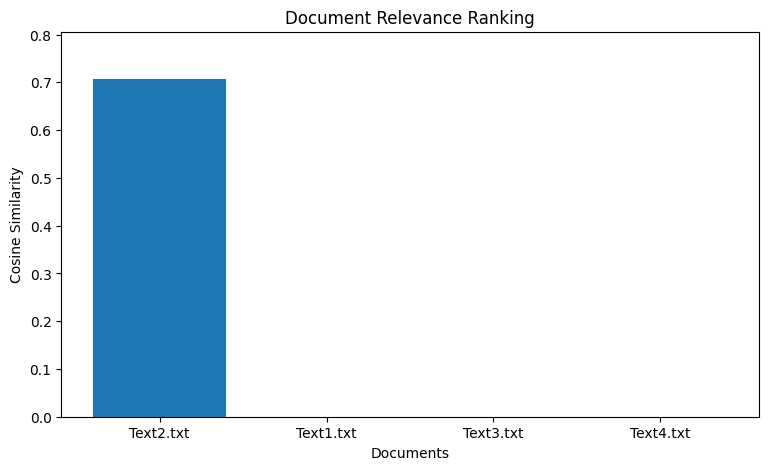

In [22]:
query = "drip irrigation water efficiency crops"

results, _ = search_documents(query)

filenames = [item[0] for item in results]
scores = [item[1] for item in results]

plt.figure(figsize=(9, 5))

plt.bar(filenames, scores)

plt.xlabel("Documents")
plt.ylabel("Cosine Similarity")
plt.title("Document Relevance Ranking")

plt.ylim(0, max(scores) + 0.1)

plt.show()

In [23]:
test_queries = [
    "soil nutrients crop growth fertilizer",
    "drip irrigation water efficiency crops",
    "insects pests crop disease prevention",
    "organic manure sustainable farming"
]

for query in test_queries:
    results, _ = search_documents(query)

    print("=" * 70)
    print("QUERY:", query)
    print("-" * 70)

    for rank, (filename, score) in enumerate(results, start=1):
        print(f"{rank}. {filename} -> {score:.4f}")

QUERY: soil nutrients crop growth fertilizer
----------------------------------------------------------------------
1. Text1.txt -> 0.6129
2. Text4.txt -> 0.1523
3. Text2.txt -> 0.0205
4. Text3.txt -> 0.0000
QUERY: drip irrigation water efficiency crops
----------------------------------------------------------------------
1. Text2.txt -> 0.7060
2. Text1.txt -> 0.0000
3. Text3.txt -> 0.0000
4. Text4.txt -> 0.0000
QUERY: insects pests crop disease prevention
----------------------------------------------------------------------
1. Text3.txt -> 0.5031
2. Text4.txt -> 0.0224
3. Text1.txt -> 0.0000
4. Text2.txt -> 0.0000
QUERY: organic manure sustainable farming
----------------------------------------------------------------------
1. Text4.txt -> 0.5098
2. Text3.txt -> 0.0239
3. Text1.txt -> 0.0223
4. Text2.txt -> 0.0000


# Conclusion

The Agricultural Information Retrieval System successfully retrieves and ranks agricultural documents based on a user's query.

The system applies:

1. Text preprocessing
2. Tokenization
3. Stopword removal
4. Stemming
5. Term Frequency calculation
6. Document Frequency calculation
7. Inverse Document Frequency calculation
8. TF-IDF calculation
9. Query vector generation
10. Cosine Similarity
11. Document ranking

The document with the highest cosine similarity score is considered the most relevant document for the user's query.

## Result

The project demonstrates how Natural Language Processing and Information Retrieval techniques can be applied to agricultural information search.